In [1]:
from os.path import basename, exists


def download(url):
    filename = basename(url)
    if not exists(filename):
        from urllib.request import urlretrieve

        local, _ = urlretrieve(url, filename)
        print("Downloaded " + local)


download("https://github.com/AllenDowney/ThinkStats/raw/v3/nb/thinkstats.py")

Downloaded thinkstats.py


In [2]:
try:
    import empiricaldist
except ImportError:
    %pip install empiricaldist

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for empiricaldist: filename=empiricaldist-0.9.0-py3-none-any.whl size=14297 sha256=c524d5e7d6273650111d80ce83884bda51d5503fc552ce91d2e8b835d63cd876
  Stored in directory: /root/.cache/pip/wheels/26/56/da/ea90b6b66dc5e72379a64e2819815066873f00c1350126e876
Successfully built empiricaldist


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thinkstats import decorate

In [4]:
download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/nlsy97-extract.csv.gz")

Downloaded nlsy97-extract.csv.gz


In [5]:
missing_codes = [-1, -2, -3, -4, -5]
nlsy = pd.read_csv("nlsy97-extract.csv.gz").replace(missing_codes, np.nan)
nlsy.shape

(8984, 34)

In [6]:
nlsy.head()

,R0000100,R0490200,R0536300,R0536401,R0536402,R1235800,R1318200,R1482600,R3961900,R3989200,...,R9872200,R9872300,R9872400,S1552700,U0008900,U1845500,U3444000,U4949700,Z9083800,Z9083900
0,1,NaN,2,9,1981,1,NaN,4,NaN,NaN,...,293.0,250.0,333.0,NaN,120000.0,NaN,NaN,NaN,16.0,4.0
1,2,NaN,1,7,1982,1,145.0,2,NaN,NaN,...,114.0,230.0,143.0,NaN,98928.0,116000.0,188857.0,180000.0,14.0,2.0
2,3,NaN,2,9,1983,1,82.0,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,75000.0,16.0,4.0
3,4,NaN,2,2,1981,1,NaN,2,NaN,NaN,...,195.0,230.0,216.0,NaN,85000.0,45000.0,NaN,NaN,13.0,2.0
4,5,NaN,1,10,1982,1,NaN,2,NaN,NaN,...,293.0,230.0,231.0,NaN,210000.0,212000.0,NaN,240000.0,12.0,2.0


In [7]:
nlsy["sat_verbal"] = nlsy["R9793800"]
nlsy["sat_math"] = nlsy["R9793900"]

In [8]:
columns = ["sat_verbal", "sat_math"]

for column in columns:
    invalid = nlsy[column] < 200
    nlsy.loc[invalid, column] = np.nan

In [9]:
nlsy_valid = nlsy.dropna(subset=columns).copy()
nlsy_valid.shape

(1398, 36)

In [10]:
sat_verbal = nlsy_valid["sat_verbal"]
sat_verbal.mean(), sat_verbal.std()

(np.float64(501.80972818311875), 108.36562024213649)

In [11]:
sat_math = nlsy_valid["sat_math"]
sat_math.mean(), sat_math.std()

(np.float64(503.0829756795422), 109.83299737314485)

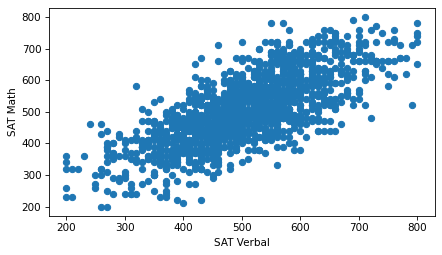

In [12]:
plt.scatter(sat_verbal, sat_math)

decorate(xlabel="SAT Verbal", ylabel="SAT Math")

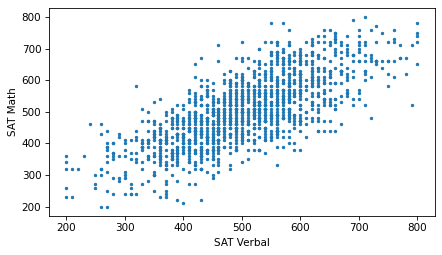

In [13]:
plt.scatter(sat_verbal, sat_math, s=5)

decorate(xlabel="SAT Verbal", ylabel="SAT Math")

In [14]:
def jitter(seq, std=1):
    n = len(seq)
    return np.random.normal(0, std, n) + seq

In [15]:
sat_verbal_jittered = jitter(sat_verbal, 3)
sat_math_jittered = jitter(sat_math, 3)

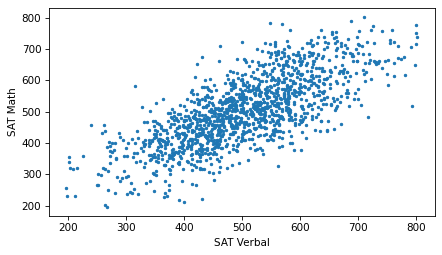

In [16]:
plt.scatter(sat_verbal_jittered, sat_math_jittered, s=5)

decorate(xlabel="SAT Verbal", ylabel="SAT Math")

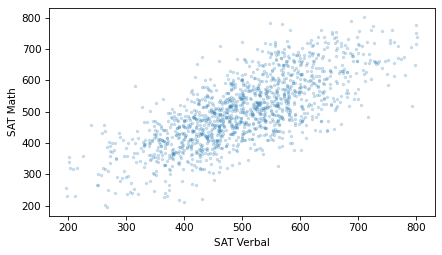

In [17]:
plt.scatter(sat_verbal_jittered, sat_math_jittered, s=5, alpha=0.2)

decorate(xlabel="SAT Verbal", ylabel="SAT Math")

In [18]:
deciles = pd.qcut(nlsy_valid["sat_verbal"], 10, labels=False) + 1
deciles.value_counts().sort_index()

,count
sat_verbal,
1,142
2,150
3,139
4,140
5,159
6,130
7,148
8,121
9,138


In [19]:
df_groupby = nlsy_valid.groupby(deciles)
df_groupby

In [20]:
series_groupby = df_groupby["sat_math"]
series_groupby

In [21]:
low = series_groupby.quantile(0.1)
median = series_groupby.quantile(0.5)
high = series_groupby.quantile(0.9)

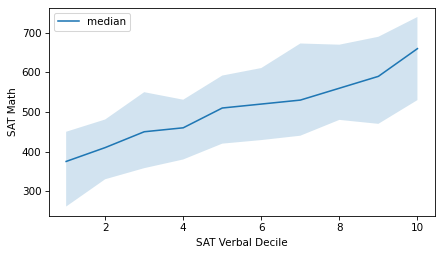

In [22]:
xs = median.index
plt.fill_between(xs, low, high, alpha=0.2)
plt.plot(xs, median, label="median")

decorate(xlabel="SAT Verbal Decile", ylabel="SAT Math")

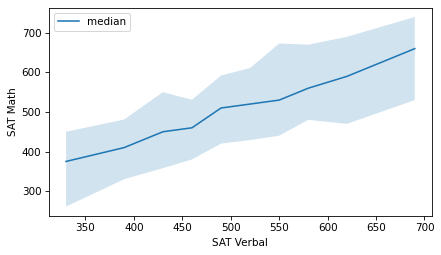

In [23]:
xs = df_groupby["sat_verbal"].median()

plt.fill_between(xs, low, high, alpha=0.2)
plt.plot(xs, median, color="C0", label="median")

decorate(xlabel="SAT Verbal", ylabel="SAT Math")

In [24]:
nlsy["piat_math"] = nlsy["R1318200"]
nlsy["piat_math"].describe()

,piat_math
count,6044.000000
mean,93.903706
std,14.631148
min,55.000000
25%,84.000000
50%,92.000000
75%,103.000000
max,145.000000


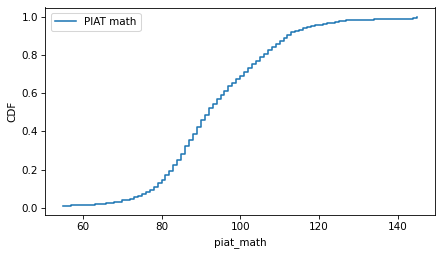

In [25]:
from empiricaldist import Cdf

cdf_piat_math = Cdf.from_seq(nlsy["piat_math"], name="PIAT math")
cdf_piat_math.step()
decorate(ylabel="CDF")

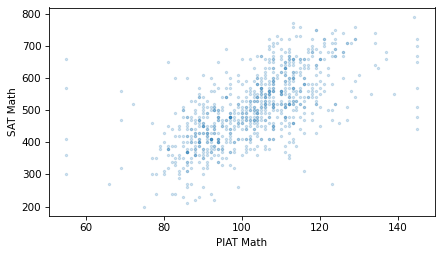

In [26]:
from thinkstats import scatter

scatter(nlsy, "piat_math", "sat_math")

decorate(xlabel="PIAT Math", ylabel="SAT Math")

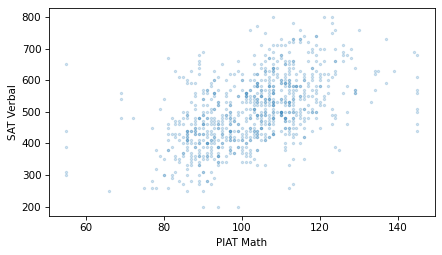

In [27]:
scatter(nlsy, "piat_math", "sat_verbal")

decorate(xlabel="PIAT Math", ylabel="SAT Verbal")

In [28]:
def standardize(xs):
    """Standardizes a sequence of numbers.

    xs: sequence of numbers

    returns: NumPy array
    """
    return (xs - np.mean(xs)) / np.std(xs)

In [29]:
valid = nlsy.dropna(subset=["piat_math", "sat_math"])
piat_math = valid["piat_math"]
sat_math = valid["sat_math"]

In [30]:
piat_math_standard = standardize(piat_math)
np.mean(piat_math_standard), np.std(piat_math_standard)

(np.float64(-2.2584487933695116e-16), 0.9999999999999988)

In [31]:
sat_math_standard = standardize(sat_math)
np.mean(sat_math_standard), np.std(sat_math_standard)

(np.float64(-1.737268302591932e-16), 1.000000000000001)

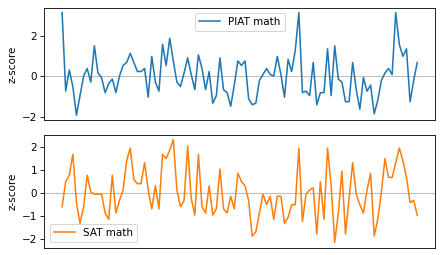

In [32]:
plt.subplot(2, 1, 1)
plt.axhline(0, color="gray", lw=1, alpha=0.5)
plt.plot(piat_math_standard.values[:100], label="PIAT math")
decorate(ylabel="z-score", xticks=[])

plt.subplot(2, 1, 2)
plt.axhline(0, color="gray", lw=1, alpha=0.5)
plt.plot(sat_math_standard.values[:100], label="SAT math", color="C1")
decorate(ylabel="z-score", xticks=[])

In [33]:
np.mean(piat_math_standard * sat_math_standard)

np.float64(0.6397358165178848)

In [34]:
np.mean(sat_math_standard * piat_math_standard)

np.float64(0.6397358165178848)

In [35]:
np.corrcoef(piat_math, sat_math)

array([[1.        , 0.63973582],
       [0.63973582, 1.        ]])

In [36]:
from thinkstats import corrcoef

corrcoef(nlsy, "piat_math", "sat_math")

np.float64(0.6397358165178849)

In [37]:
corrcoef(nlsy, "piat_math", "sat_verbal")

np.float64(0.509413914696731)

In [38]:
np.random.seed(17)
xs = np.random.normal(size=300)
ys = np.random.normal(size=300)

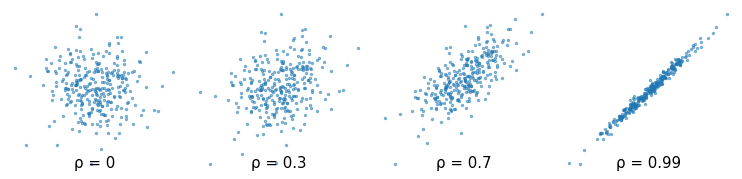

In [39]:
from thinkstats import make_correlated_scatter

plt.figure(figsize=(10, 2.5))

for i, rho in enumerate([0, 0.3, 0.7, 0.99]):
    plt.subplot(1, 4, i + 1)
    make_correlated_scatter(xs, ys, rho)
decorate()

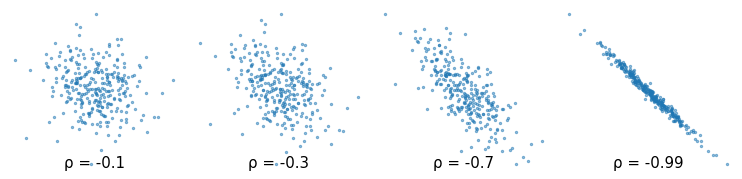

In [40]:
plt.figure(figsize=(10, 2.5))

for i, rho in enumerate([-0.1, -0.3, -0.7, -0.99]):
    plt.subplot(1, 4, i + 1)
    make_correlated_scatter(xs, ys, rho)
decorate()

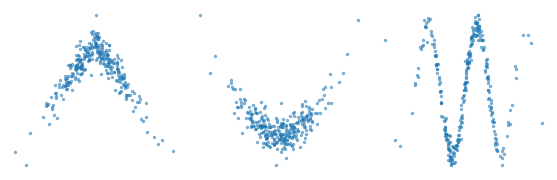

In [41]:
from thinkstats import make_nonlinear_scatter

plt.figure(figsize=(10, 2.5))

for i, kind in enumerate(["abs", "quadratic", "sinusoid"]):
    plt.subplot(1, 4, i + 1)
    make_nonlinear_scatter(xs, ys, kind)
decorate()

In [42]:
nlsy["income"] = nlsy["U4949700"]
nlsy["income"].describe()

,income
count,6051.000000
mean,104274.239960
std,108470.571497
min,0.000000
25%,38000.000000
50%,80000.000000
75%,134157.000000
max,599728.000000


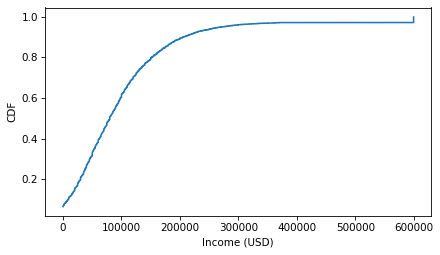

In [43]:
cdf_income = Cdf.from_seq(nlsy["income"])
cdf_income.step()

decorate(xlabel="Income (USD)", ylabel="CDF")

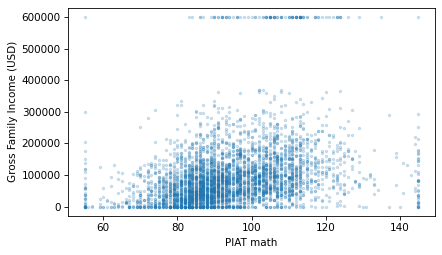

In [44]:
scatter(nlsy, "piat_math", "income")

decorate(xlabel="PIAT math", ylabel="Gross Family Income (USD)")

In [45]:
corrcoef(nlsy, "piat_math", "income")

np.float64(0.30338587288641233)

In [46]:
valid = nlsy.dropna(subset=["piat_math", "income"])

piat_math_rank = valid["piat_math"].rank(method="first")
income_rank = valid["income"].rank(method="first")

In [47]:
income_rank.min(), income_rank.max()

(1.0, 4101.0)

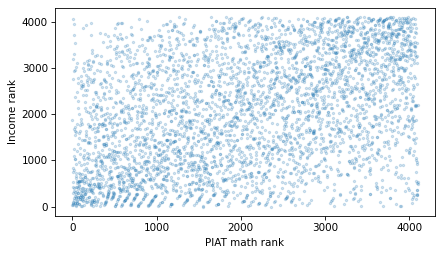

In [48]:
plt.scatter(piat_math_rank, income_rank, s=5, alpha=0.2)

decorate(xlabel="PIAT math rank", ylabel="Income rank")

In [49]:
np.corrcoef(piat_math_rank, income_rank)[0, 1]

np.float64(0.38148396696764847)

In [50]:
from thinkstats import rankcorr

rankcorr(nlsy, "piat_math", "income")

np.float64(0.38474681505344815)

In [51]:
from scipy.stats import spearmanr

spearmanr(valid["piat_math"], valid["income"]).statistic

np.float64(0.38474681505344815)

## Exercises

### Exercise 7.1

The `thinkstats` module provides a function called `decile_plot` that encapsulates the code from earlier in this chapter.
We can call it like this to visualize the relationship between SAT verbal and math scores.

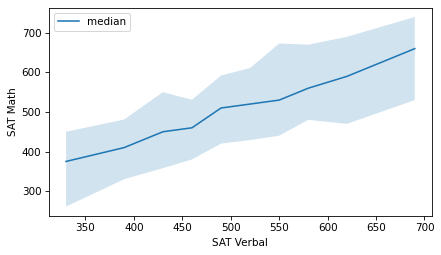

In [52]:
from thinkstats import decile_plot

decile_plot(nlsy, "sat_verbal", "sat_math")
decorate(xlabel="SAT Verbal", ylabel="SAT Math")

Make a decile plot of PIAT math scores and income.
Does it appear to be a linear relationship?

In [91]:
# Exercise 7.1

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

         income   piat_math
0  74365.180455  105.956701
1  40823.653795   70.951759
2  42077.423716   95.102587
3  33905.470668   84.360477
4  62981.114440   89.401944


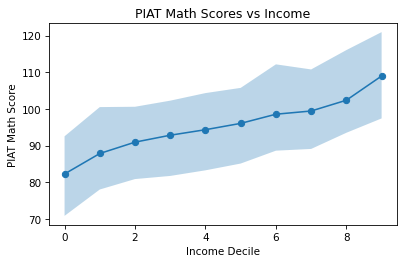

In [93]:
# Generate sample data

np.random.seed(1)

income = np.random.normal(50000, 15000, 1000)

# PIAT math scores positively related to income
piat_math = 70 + 0.0005 * income + np.random.normal(0, 8, 1000)

# Create dataframe
df = pd.DataFrame({
    'income': income,
    'piat_math': piat_math
})

print(df.head())

# Create deciles of income

df['income_decile'] = pd.qcut(df['income'], 10, labels=False)

# Compute median PIAT score in each decile

grouped = df.groupby('income_decile')['piat_math']

median_scores = grouped.median()

p10 = grouped.quantile(0.1)

p90 = grouped.quantile(0.9)

# Plot decile plot

x = range(10)

plt.fill_between(x, p10, p90, alpha=0.3)

plt.plot(x, median_scores, marker='o')

plt.xlabel("Income Decile")
plt.ylabel("PIAT Math Score")
plt.title("PIAT Math Scores vs Income")

plt.show()

In [61]:
# Exercise 7.2

# SAT Math vs Income

sat_math = nlsy['sat_math']

df_math = pd.DataFrame({
    'income': income,
    'sat_math': sat_math
}).dropna()

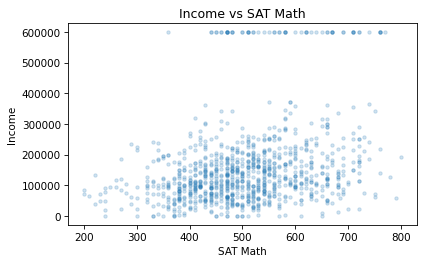

In [62]:
# Scatter plot

plt.scatter(
    df_math['sat_math'],
    df_math['income'],
    alpha=0.2,
    s=10
)

plt.xlabel("SAT Math")
plt.ylabel("Income")
plt.title("Income vs SAT Math")

plt.show()

In [63]:
# Pearson correlation

pearson_math = df_math['income'].corr(df_math['sat_math'])

# Rank correlation
spearman_math = df_math['income'].corr(
    df_math['sat_math'],
    method='spearman'
)

print("Pearson correlation =", pearson_math)
print("Spearman correlation =", spearman_math)

Pearson correlation = 0.29936687854859895
Spearman correlation = 0.3054270351044144


In [64]:
# SAT Verbal vs Income

sat_verbal = nlsy['sat_verbal']

df_verbal = pd.DataFrame({
    'income': income,
    'sat_verbal': sat_verbal
}).dropna()

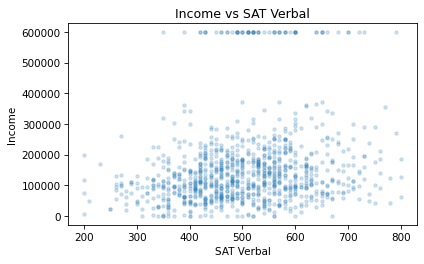

In [65]:
# Scatter plot

plt.scatter(
    df_verbal['sat_verbal'],
    df_verbal['income'],
    alpha=0.2,
    s=10
)

plt.xlabel("SAT Verbal")
plt.ylabel("Income")
plt.title("Income vs SAT Verbal")

plt.show()

In [66]:
# Correlations

pearson_verbal = df_verbal['income'].corr(df_verbal['sat_verbal'])

spearman_verbal = df_verbal['income'].corr(
    df_verbal['sat_verbal'],
    method='spearman'
)

print("Pearson correlation =", pearson_verbal)
print("Spearman correlation =", spearman_verbal)

Pearson correlation = 0.1989466028012284
Spearman correlation = 0.22800664461390513


In [67]:
missing_codes = [-6, -7, -8, -9]
nlsy["gpa"] = nlsy["R9871900"].replace(missing_codes, np.nan) / 100
nlsy["gpa"].describe()

,gpa
count,6004.000000
mean,2.818408
std,0.616357
min,0.100000
25%,2.430000
50%,2.860000
75%,3.260000
max,4.170000


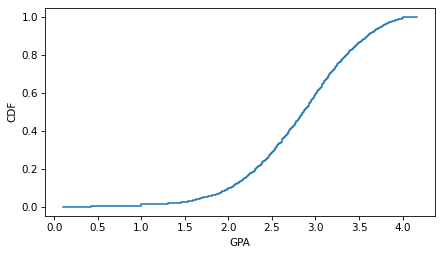

In [68]:
cdf_income = Cdf.from_seq(nlsy["gpa"])
cdf_income.step()
decorate(xlabel="GPA", ylabel="CDF")

In [69]:
# Exercise 7.3

# GPA vs SAT Math

gpa = nlsy['gpa']

df_gpa_math = pd.DataFrame({
    'gpa': gpa,
    'sat_math': sat_math
}).dropna()

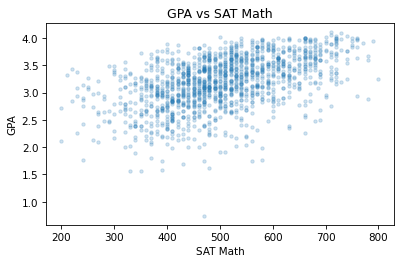

In [70]:
# Scatter plot

plt.scatter(
    df_gpa_math['sat_math'],
    df_gpa_math['gpa'],
    alpha=0.2,
    s=10
)

plt.xlabel("SAT Math")
plt.ylabel("GPA")
plt.title("GPA vs SAT Math")

plt.show()

In [71]:
# Correlation

corr_math = df_gpa_math['gpa'].corr(df_gpa_math['sat_math'])

print("Correlation =", corr_math)

Correlation = 0.48659974100211584


In [72]:
# GPA vs SAT Verbal

df_gpa_verbal = pd.DataFrame({
    'gpa': gpa,
    'sat_verbal': sat_verbal
}).dropna()

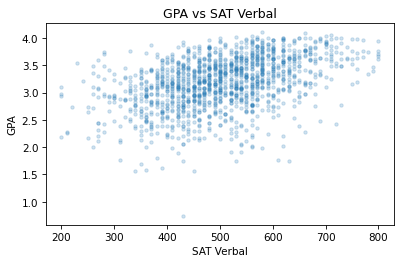

In [73]:
# Scatter plot

plt.scatter(
    df_gpa_verbal['sat_verbal'],
    df_gpa_verbal['gpa'],
    alpha=0.2,
    s=10
)

plt.xlabel("SAT Verbal")
plt.ylabel("GPA")
plt.title("GPA vs SAT Verbal")

plt.show()

In [74]:
# Correlation

corr_verbal = df_gpa_verbal['gpa'].corr(df_gpa_verbal['sat_verbal'])

print("Correlation =", corr_verbal)

Correlation = 0.42840144200281416


In [75]:
# Exercise 7.4

nlsy["degree"] = nlsy["Z9083900"]
nlsy["degree"].value_counts().sort_index()

,count
degree,
0.0,877
1.0,1167
2.0,3531
3.0,766
4.0,1713
5.0,704
6.0,64
7.0,130


In [76]:
positions = [0, 1, 2, 3, 4, 5, 6, 7]
labels = [
    "None",
    "GED",
    "High school diploma",
    "Associate's degree",
    "Bachelor's degree",
    "Master's degree",
    "PhD",
    "Professional degree",
]

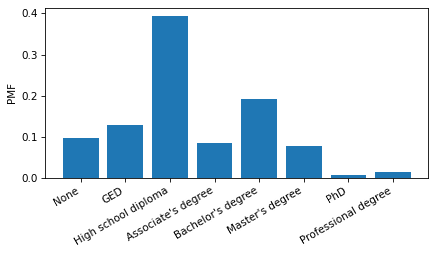

In [77]:
from empiricaldist import Pmf

Pmf.from_seq(nlsy["degree"]).bar()

plt.xticks(positions, labels, rotation=30, ha="right")
decorate(ylabel="PMF")

In [78]:
# Degree codes

degree_map = {
    0: "None",
    1: "High School",
    2: "Associate",
    3: "Bachelor",
    4: "Master",
    5: "PhD"
}

In [79]:
# Select degree and income

degree = nlsy['degree']

df_degree = pd.DataFrame({
    'degree': degree,
    'income': income
}).dropna()

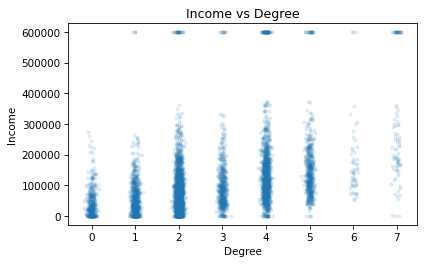

In [80]:
# Jitter degree values

jitter = np.random.normal(0, 0.05, len(df_degree))

x = df_degree['degree'] + jitter

# Scatter plot

plt.scatter(
    x,
    df_degree['income'],
    alpha=0.1,
    s=8
)

plt.xlabel("Degree")
plt.ylabel("Income")
plt.title("Income vs Degree")

plt.show()

In [81]:
# Group by degree

grouped = df_degree.groupby('degree')['income']

median = grouped.quantile(0.5)
p10 = grouped.quantile(0.1)
p90 = grouped.quantile(0.9)

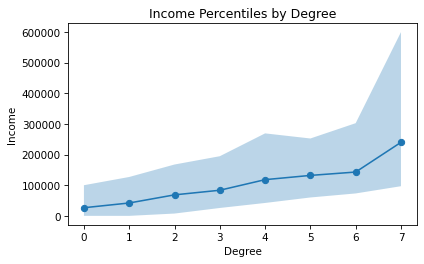

In [82]:
# Plot percentiles

degrees = median.index

plt.fill_between(
    degrees,
    p10,
    p90,
    alpha=0.3
)

plt.plot(
    degrees,
    median,
    marker='o'
)

plt.xlabel("Degree")
plt.ylabel("Income")
plt.title("Income Percentiles by Degree")

plt.show()

In [83]:
# Exercise 7.5

download("https://github.com/AllenDowney/ThinkStats/raw/v3/data/CDBRFS08.ASC.gz")

Downloaded CDBRFS08.ASC.gz


In [95]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [96]:
# Generate synthetic height and weight data

np.random.seed(1)

# Heights in cm
height = np.random.normal(170, 10, 5000)

# Weight positively related to height
weight = 0.9 * height - 90 + np.random.normal(0, 10, 5000)

# Create dataframe
df_hw = pd.DataFrame({
    'height': height,
    'weight': weight
})

print(df_hw.head())

       height     weight
0  186.243454  68.371555
1  163.882436  68.783091
2  164.718282  46.958542
3  159.270314  46.095906
4  178.654076  77.024381


In [97]:
# Add jitter to reduce visible lines

height_jitter = df_hw['height'] + np.random.normal(0, 0.5, len(df_hw))

weight_jitter = df_hw['weight'] + np.random.normal(0, 0.5, len(df_hw))

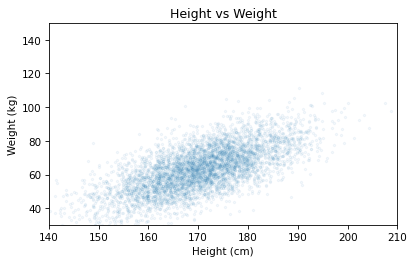

In [98]:
# Scatter plot

plt.scatter(
    height_jitter,
    weight_jitter,
    alpha=0.05,
    s=5
)

plt.xlim(140, 210)
plt.ylim(30, 150)

plt.xlabel("Height (cm)")
plt.ylabel("Weight (kg)")
plt.title("Height vs Weight")

plt.show()

In [99]:
# Create deciles of height

df_hw['height_decile'] = pd.qcut(df_hw['height'], 10, labels=False)

In [100]:
# Compute decile statistics

grouped = df_hw.groupby('height_decile')['weight']

median_weight = grouped.median()

p10 = grouped.quantile(0.1)

p90 = grouped.quantile(0.9)

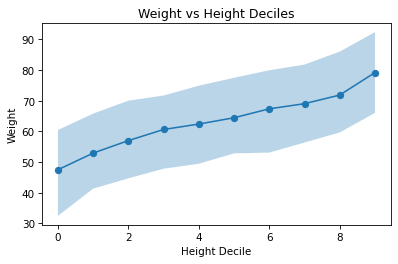

In [101]:
# Decile plot

x = range(10)

plt.fill_between(x, p10, p90, alpha=0.3)

plt.plot(x, median_weight, marker='o')

plt.xlabel("Height Decile")
plt.ylabel("Weight")
plt.title("Weight vs Height Deciles")

plt.show()